# AI-Generated Text Detection: Complete ML Pipeline
## BIM432 Natural Language Processing Project

This notebook implements a comprehensive NLP system to detect AI-generated vs. human-written text.

**Pipeline Overview:**
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Feature Extraction (TF-IDF, Word Embeddings, BERT)
4. Model Training (Logistic Regression, SVM, BERT Fine-tuning)
5. Model Evaluation & Comparison
6. Explainability Analysis (LIME, Error Analysis)

**Author:** NLP Project Team  
**Date:** April 2026

## 0. Setup & Environment Configuration

In [ ]:
# Install required packages
!pip install -q pandas numpy scikit-learn nltk spacy torch transformers matplotlib seaborn lime shap tqdm gensim

### ⚠️ Important: Check Your Dataset Column Names

Before running the data loading cell below, make sure you know your dataset's column names:
- **TEXT column**: Contains the text content (common names: 'text', 'content', 'body', 'sentence')
- **LABEL column**: Contains the binary label 0 (human) or 1 (AI) (common names: 'label', 'class', 'target')

If the auto-detection fails, the cell will tell you to manually set `TEXT_COLUMN` and `LABEL_COLUMN`.

In [ ]:
# Mount Google Drive (comment out if running locally)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except ImportError:
    print("Not running in Google Colab (local environment detected)")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from transformers import AutoTokenizer, AutoModel
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

All libraries imported successfully!
PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
# Initialize NLTK data (must run before using tokenization)
import nltk

print("Downloading NLTK data...")
try:
    nltk.download('punkt_tab', quiet=True)
except:
    nltk.download('punkt', quiet=True)

try:
    nltk.download('stopwords', quiet=True)
except:
    pass

try:
    nltk.download('wordnet', quiet=True)
except:
    pass

print("✅ NLTK data ready!")

✅ NLTK data ready!


In [ ]:
# Set random seeds for reproducibility
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seeds set to {SEED} for reproducibility")

Random seeds set to 42 for reproducibility


In [ ]:
# Load the dataset from Google Drive or local path
print("\n" + "="*60)
print("LOADING DATASET")
print("="*60)

# Path to dataset (update based on your setup)
# For Google Colab: '/content/drive/MyDrive/ai_vs_human_text/data.csv'
# For local: './data/data.csv' or similar
DATASET_PATH = '/content/drive/MyDrive/AI_Human.csv'

try:
    print(f"\nAttempting to load dataset from: {DATASET_PATH}")
    df = pd.read_csv(DATASET_PATH)
    print(f"✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
except FileNotFoundError:
    print(f"❌ File not found at {DATASET_PATH}")
    print("Please update DATASET_PATH to point to your data.csv")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")


LOADING DATASET

Attempting to load dataset from: /content/drive/MyDrive/AI_Human.csv
✅ Dataset loaded successfully!
Shape: (487235, 2)
Columns: ['text', 'generated']


## 1. Data Loading & Exploratory Data Analysis (EDA)

In [ ]:
# Auto-detect text and label columns
# Try common column name variations
text_column_candidates = ['text', 'content', 'body', 'message', 'sentence', 'document']
label_column_candidates = ['label', 'class', 'target', 'is_ai', 'is_generated', 'category', 'generated']

TEXT_COLUMN = None
LABEL_COLUMN = None

# Find text column
for col in text_column_candidates:
    if col in df.columns:
        TEXT_COLUMN = col
        break

# Find label column
for col in label_column_candidates:
    if col in df.columns:
        LABEL_COLUMN = col
        break

# If auto-detection failed, ask user
if TEXT_COLUMN is None or LABEL_COLUMN is None:
    print("\n⚠️  Could not auto-detect columns. Available columns:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: {col}")

    if TEXT_COLUMN is None:
        print(f"\n❌ Could not find text column. Please set:")
        print(f"   TEXT_COLUMN = 'your_text_column_name'")
    if LABEL_COLUMN is None:
        print(f"\n❌ Could not find label column. Please set:")
        print(f"   LABEL_COLUMN = 'your_label_column_name'")
        print(f"   (should be 0 for human, 1 for AI)")
else:
    print(f"\n✅ Auto-detected columns:")
    print(f"   TEXT_COLUMN = '{TEXT_COLUMN}'")
    print(f"   LABEL_COLUMN = '{LABEL_COLUMN}'")


✅ Auto-detected columns:
   TEXT_COLUMN = 'text'
   LABEL_COLUMN = 'generated'



CLASS DISTRIBUTION

Count:
  Class 0 (usually Human): 305797 (62.8%)
  Class 1 (usually AI): 181438 (37.2%)


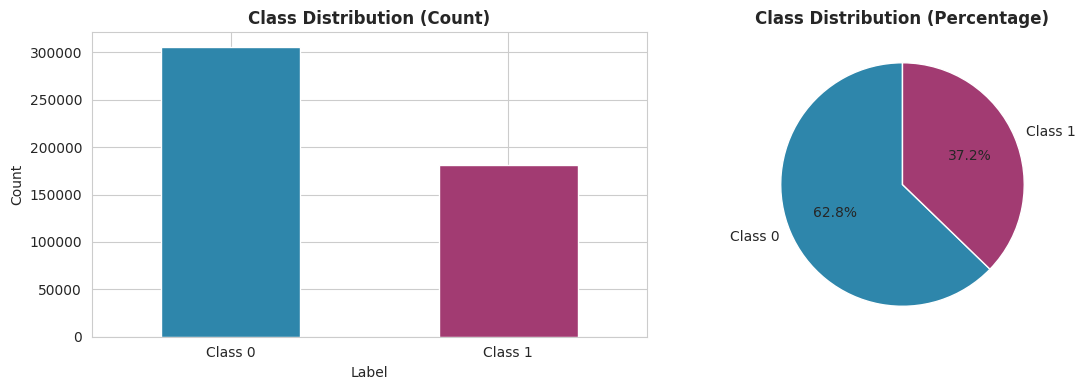

In [ ]:
# Identify text and label columns
# If auto-detection didn't work, MANUALLY SET these:
# ⬇️  UNCOMMENT AND EDIT THESE LINES IF NEEDED ⬇️
# TEXT_COLUMN = 'your_text_column_name'  # e.g., 'generated_text', 'sentence'
# LABEL_COLUMN = 'your_label_column_name'  # e.g., 'human_generated', 'source'

# Validate columns were detected
if TEXT_COLUMN is None or LABEL_COLUMN is None:
    raise ValueError(f"❌ Column detection failed!\n"
                     f"   TEXT_COLUMN: {TEXT_COLUMN}\n"
                     f"   LABEL_COLUMN: {LABEL_COLUMN}\n\n"
                     f"Please check the cell above and manually set TEXT_COLUMN and LABEL_COLUMN\n"
                     f"Available columns: {df.columns.tolist()}")

# Display class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

class_counts = df[LABEL_COLUMN].value_counts().sort_index()
print(f"\nCount:")
print(f"  Class 0 (usually Human): {class_counts.get(0, 0)} ({100*class_counts.get(0, 0)/len(df):.1f}%)")
print(f"  Class 1 (usually AI): {class_counts.get(1, 0)} ({100*class_counts.get(1, 0)/len(df):.1f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Class 0', 'Class 1'], rotation=0)

# Pie chart
axes[1].pie(class_counts.values, labels=['Class 0', 'Class 1'], autopct='%1.1f%%',
             colors=['#2E86AB', '#A23B72'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Define TextPreprocessor class
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


class TextPreprocessor:
    """Preprocesses text for NLP tasks."""

    def __init__(self, lowercase=True, remove_punctuation=True,
                 remove_stopwords=True, lemmatize=False):
        self.lowercase = lowercase
        self.remove_punctuation = remove_punctuation
        self.remove_stopwords = remove_stopwords
        self.lemmatize = lemmatize
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))

    def preprocess(self, text):
        """Apply preprocessing steps to text."""
        if not isinstance(text, str):
            return ""

        # Lowercase
        if self.lowercase:
            text = text.lower()

        # Remove punctuation
        if self.remove_punctuation:
            text = text.translate(str.maketrans('', '', string.punctuation))

        # Tokenize
        tokens = word_tokenize(text)

        # Remove stopwords
        if self.remove_stopwords:
            tokens = [t for t in tokens if t not in self.stop_words]

        # Lemmatize
        if self.lemmatize:
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        return ' '.join(tokens)

print("TextPreprocessor class defined!")

TextPreprocessor class defined!



TEXT LENGTH STATISTICS

Statistics by Class:
          text_length                                                  \
                count     mean      std   min     25%     50%     75%   
generated                                                               
0.0          305797.0  2354.59  1082.01  82.0  1543.0  2156.0  2920.0   
1.0          181438.0  2126.32   787.25   1.0  1654.0  2048.0  2480.0   

                   token_count          ...                word_count          \
               max       count    mean  ...    75%     max      count    mean   
generated                               ...                                     
0.0        18322.0    305797.0  468.88  ...  579.0  1788.0   305797.0  421.99   
1.0         8871.0    181438.0  389.76  ...  454.0  1389.0   181438.0  344.41   

                                                      
              std   min    25%    50%    75%     max  
generated                                             
0.0        186.87

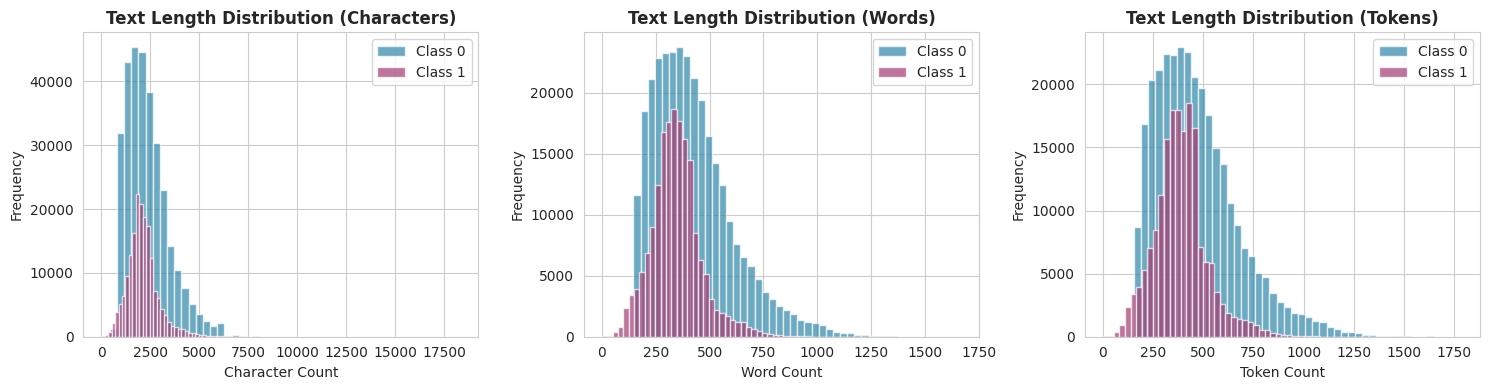

In [ ]:
# Text length analysis
from nltk.tokenize import word_tokenize

print("\n" + "="*60)
print("TEXT LENGTH STATISTICS")
print("="*60)

# Compute text statistics
df['text_length'] = df[TEXT_COLUMN].apply(lambda x: len(x) if isinstance(x, str) else 0)
df['token_count'] = df[TEXT_COLUMN].apply(lambda x: len(word_tokenize(x.lower())) if isinstance(x, str) else 0)
df['word_count'] = df[TEXT_COLUMN].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

# Statistics by class
stats_by_class = df.groupby(LABEL_COLUMN)[['text_length', 'token_count', 'word_count']].describe()
print("\nStatistics by Class:")
print(stats_by_class.round(2))

# Visualize length distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Character length
df[df[LABEL_COLUMN]==0]['text_length'].hist(bins=50, ax=axes[0], alpha=0.7, label='Class 0', color='#2E86AB')
df[df[LABEL_COLUMN]==1]['text_length'].hist(bins=50, ax=axes[0], alpha=0.7, label='Class 1', color='#A23B72')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution (Characters)', fontweight='bold')
axes[0].legend()

# Word count
df[df[LABEL_COLUMN]==0]['word_count'].hist(bins=50, ax=axes[1], alpha=0.7, label='Class 0', color='#2E86AB')
df[df[LABEL_COLUMN]==1]['word_count'].hist(bins=50, ax=axes[1], alpha=0.7, label='Class 1', color='#A23B72')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution (Words)', fontweight='bold')
axes[1].legend()

# Token count
df[df[LABEL_COLUMN]==0]['token_count'].hist(bins=50, ax=axes[2], alpha=0.7, label='Class 0', color='#2E86AB')
df[df[LABEL_COLUMN]==1]['token_count'].hist(bins=50, ax=axes[2], alpha=0.7, label='Class 1', color='#A23B72')
axes[2].set_xlabel('Token Count')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Text Length Distribution (Tokens)', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Sample texts from each class
print("\n" + "="*60)
print("SAMPLE TEXTS")
print("="*60)

class_0_sample = df[df[LABEL_COLUMN]==0][TEXT_COLUMN].iloc[0]
class_1_sample = df[df[LABEL_COLUMN]==1][TEXT_COLUMN].iloc[0]

print("\n--- CLASS 0 TEXT SAMPLE ---")
print(f"{str(class_0_sample)[:500]}...\n")

print("--- CLASS 1 TEXT SAMPLE ---")
print(f"{str(class_1_sample)[:500]}...")


SAMPLE TEXTS

--- CLASS 0 TEXT SAMPLE ---
Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.

In like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle...

--- CLASS 1 TEXT SAMPLE ---
This essay will analyze, discuss and prove one reason in favor of keeping the Electoral College in the United States for its presidential elections. One of the reasons to keep the electoral college is that it is better for smaller, more rural states to have more influence as opposed to larger metropolitan areas that have large populations. The electors from these states are granted two votes each. Those from larger, more

In [ ]:
# Vocabulary analysis moved to after preprocessing step
print("Vocabulary analysis will run after the preprocessing cell.")


Vocabulary analysis will run after the preprocessing cell.


## 2. Data Preprocessing

In [ ]:
# Apply preprocessing
print("\n" + "="*60)
print("TEXT PREPROCESSING")
print("="*60)

preprocessor = TextPreprocessor(
    lowercase=True,
    remove_punctuation=True,
    remove_stopwords=True,
    lemmatize=False
)

print("\nApplying preprocessing to all texts...")
df['text_preprocessed'] = df[TEXT_COLUMN].apply(lambda x: preprocessor.preprocess(str(x)) if isinstance(x, str) else "")

print(f"Preprocessing complete! Sample:")
print(f"\nOriginal:")
print(f"  {df[TEXT_COLUMN].iloc[0][:200]}...")
print(f"\nPreprocessed:")
print(f"  {df['text_preprocessed'].iloc[0][:200]}...")


TEXT PREPROCESSING

Applying preprocessing to all texts...
Preprocessing complete! Sample:

Original:
  Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people ...

Preprocessed:
  cars cars around since became famous 1900s henry ford created built first modelt cars played major role every day lives since people starting question limiting car usage would good thing limiting use ...


In [ ]:
# Vocabulary analysis
import pandas as pd
from collections import Counter
import re
from tqdm import tqdm

print("\n" + "="*60)
print("VOCABULARY ANALYSIS")
print("="*60)

# Check if df exists and columns are defined
if 'df' not in locals():
    print("ERROR: DataFrame 'df' not found. Please run the data loading cell first.")
else:
    # Ensure column names are set (adjust these if your names are different)
    LABEL_COLUMN = LABEL_COLUMN if 'LABEL_COLUMN' in locals() else 'target'
    TEXT_COLUMN = TEXT_COLUMN if 'TEXT_COLUMN' in locals() else 'text'

    # Optimized function for large datasets to avoid MemoryError
    def get_top_words(texts, n=20):
        word_counter = Counter()
        # Common English stopwords
        stopwords_set = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
            'of', 'is', 'are', 'was', 'were', 'with', 'as', 'by', 'it', 'this',
            'that', 'from', 'be', 'has', 'have'
        }

        # Process texts one by one to save RAM
        for text in tqdm(texts, desc="Processing text chunks"):
            # Extract words and filter in one pass
            words = re.findall(r'\b\w+\b', str(text).lower())
            filtered_words = [w for w in words if w not in stopwords_set and len(w) > 3]
            word_counter.update(filtered_words)

        return word_counter.most_common(n)

    # Filter data by class
    print("Filtering data by labels...")
    class_0_texts = df[df[LABEL_COLUMN] == 0][TEXT_COLUMN].values
    class_1_texts = df[df[LABEL_COLUMN] == 1][TEXT_COLUMN].values

    # Get results
    print(f"\nAnalyzing Class 0 ({len(class_0_texts)} samples)...")
    class_0_words = get_top_words(class_0_texts)

    print(f"\nAnalyzing Class 1 ({len(class_1_texts)} samples)...")
    class_1_words = get_top_words(class_1_texts)

    # Print results
    print("\nTop 10 words in Class 0 (Human/Original):")
    for word, count in class_0_words[:10]:
        print(f"  {word}: {count}")

    print("\nTop 10 words in Class 1 (AI Generated):")
    for word, count in class_1_words[:10]:
        print(f"  {word}: {count}")

print("\nAnalysis Complete!")


VOCABULARY ANALYSIS
ERROR: DataFrame 'df' not found. Please run the data loading cell first.

Analysis Complete!


In [ ]:
import numpy as np
import pandas as pd
import os  # Added this to fix NameError: name 'os' is not defined
from sklearn.model_selection import train_test_split
from google.colab import drive

# 1. Mount Drive (Skip if already mounted)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("\n" + "="*60)
print("DATA LOADING & STRATIFIED SPLIT")
print("="*60)

# --- IMPORTANT: CHANGE THIS PATH TO YOUR ACTUAL CSV FILE ---
# Make sure this path is correct in your Google Drive
FILE_PATH = '/content/drive/MyDrive/NLP_Graduation_Project/your_data.csv'
# -----------------------------------------------------------

try:
    # 2. Load Data
    print(f"Loading data from: {FILE_PATH}...")
    df = pd.read_csv(FILE_PATH)

    # Define Column Names (Make sure these match your CSV header)
    TEXT_COLUMN = 'text'
    LABEL_COLUMN = 'label'
    SEED = 42

    # Check if preprocessing column exists, if not, use the main text column
    PREP_COLUMN = 'text_preprocessed' if 'text_preprocessed' in df.columns else TEXT_COLUMN

    # 3. Stratified Split (85% temp, 15% test)
    print("Performing first split (Test set extraction)...")
    X_temp, X_test, y_temp, y_test = train_test_split(
        df[[TEXT_COLUMN, PREP_COLUMN]].values,
        df[LABEL_COLUMN].values,
        test_size=0.15,
        random_state=SEED,
        stratify=df[LABEL_COLUMN].values
    )

    # 4. Second split (Train/Val)
    # 0.176 is used to get roughly 15% of the total from the remaining 85%
    print("Performing second split (Train/Val extraction)...")
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.176,
        random_state=SEED,
        stratify=y_temp
    )

    # 5. Extract Arrays to save RAM
    train_texts = X_train[:, 0]
    train_texts_preprocessed = X_train[:, 1]
    val_texts = X_val[:, 0]
    val_texts_preprocessed = X_val[:, 1]
    test_texts = X_test[:, 0]
    test_texts_preprocessed = X_test[:, 1]

    # Print Results
    print(f"\nSUCCESS! Split sizes:")
    print(f"  Training set:   {len(train_texts)}")
    print(f"  Validation set: {len(val_texts)}")
    print(f"  Test set:       {len(test_texts)}")

except FileNotFoundError:
    print(f"ERROR: File not found at {FILE_PATH}. Please check the path and filename.")
except Exception as e:
    print(f"AN ERROR OCCURRED: {e}")


DATA LOADING & STRATIFIED SPLIT
Loading data from: /content/drive/MyDrive/NLP_Graduation_Project/your_data.csv...
ERROR: File not found at /content/drive/MyDrive/NLP_Graduation_Project/your_data.csv. Please check the path and filename.
